What is a Decision Tree?
A Decision Tree is a supervised machine learning algorithm used for both classification and regression. It models decision logic as a tree-like graph structure composed of:

Root Node: Represents the entire dataset, evaluated against the best initial split feature.

Internal/Decision Nodes: Sub-nodes where further decisions/splits are evaluated on a specific feature.

Leaf Nodes (Terminal Nodes): Nodes that do not split further; they contain the final outcome or predicted class label (e.g., Loan Approved (1) vs. Loan Defaulted (0)).

Branches: The decision paths based on feature values.

Information Gain:
-tell us features how much useful it is used in for splitting data into groups
iG = how much uncertainity is reduced after making a split
IG = entropy(parent)-weighted entropy(overall)
Entropy : - measure of uncertainity of a random varibale 
-10 passenger 
5 -D 
5-S

            age
    yes         no
    4 survived  1 survied 

    0.72 
    IG =0.28

    ID3 algorithm 
    iterative dichotomiser 3 algorithm -feature with the highest information gain at every step.
    ID = calcualte iG -> choose the highest-split-repeat 

    outlook   play?
    sunny     NO
    sunny     NO
    overcast   Yes
    rain       Yes
    rain       No

    Outllook ,temperature ,humdity ,wind 
    IG  = 
    outl=0.25
    temp=0.03
    humidty = 0.15
    wind=0.05

                outllook
        suuny overcast rain
        humidity 
        

Hyperparameters & Overfitting Mitigation
Decision trees can easily overfit by building extremely deep trees that memorize training noise. Hyperparameter tuning prevents overfitting:

max_depth: Limits the maximum depth of the tree.

min_samples_split: Minimum number of samples required to split an internal node.

min_samples_leaf: Minimum number of samples required at a leaf node.


Post- prunning:
ccp_alpha (Cost-Complexity Pruning): Controls tree pruning to balance size and accuracy.
    Tree  prunnning means removing unnecessary branches from a decision tree-to prevent overfitting.
    Traing ac= 99%  
                    ---this condtionn is called overfitting 
    Testingacc= 75% 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Configuration for plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [3]:
# Download loan_data.csv from Kaggle (https://www.kaggle.com/datasets/burak3ergun/loan-data-set)
# Load dataset into pandas
df = pd.read_csv('loan_data_set.csv')

# View the first 5 rows
print("Dataset Preview:")
df.head()

Dataset Preview:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Summary info (data types, non-null counts)
print("--- DATASET SUMMARY ---")
df.info()

print("\n--- SUMMARY STATISTICS ---")
display(df.describe().T)

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

--- DATASET SUMMARY ---
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB

--- SUMMARY STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0



--- MISSING VALUES ---
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


Target Distribution:
             Count  Percentage (%)
Loan_Status                       
Y              422       68.729642
N              192       31.270358


C:\Users\lenovo\AppData\Local\Temp\ipykernel_900\2831123163.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=df, palette='viridis')


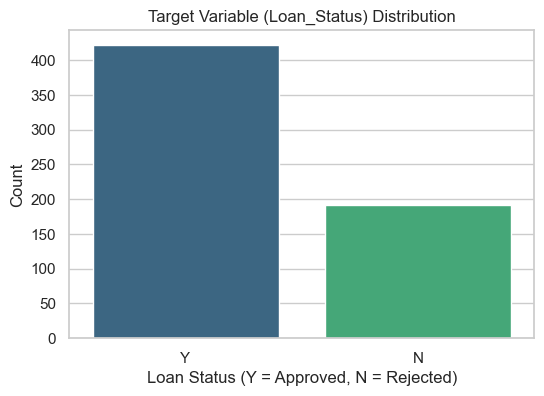

In [6]:
# Class distribution of target variable
target_counts = df['Loan_Status'].value_counts()
target_pct = df['Loan_Status'].value_counts(normalize=True) * 100

print("Target Distribution:")
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct}))

plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df, palette='viridis')
plt.title('Target Variable (Loan_Status) Distribution')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)')
plt.ylabel('Count')
plt.show()

In [7]:
# Drop Loan_ID as it is just an identifier
df_features = df.drop(columns=['Loan_ID'])

# Separate Target (y) and Features (X)
y = df_features['Loan_Status'].map({'Y': 1, 'N': 0})  # Map 'Y' -> 1, 'N' -> 0
X = df_features.drop(columns=['Loan_Status'])

print("Target variable mapped successfully. Sample values:")
print(y.head())

Target variable mapped successfully. Sample values:
0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64


In [8]:
# Categorical columns imputation (Mode)
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# Numerical columns imputation (Median)
num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Verify that no missing values remain
print("Remaining missing values:")
print(X.isnull().sum())

Remaining missing values:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [9]:
# Summary statistics for numerical features after median imputation
print("--- Numerical Features Summary ---")
display(X[['LoanAmount', 'Loan_Amount_Term']].describe().T)

# Frequency distributions for categorical features after mode imputation
print("\n--- Categorical Features Mode Check ---")
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    print(f"\n{col} distribution:")
    print(X[col].value_counts(dropna=False))

--- Numerical Features Summary ---


,count,mean,std,min,25%,50%,75%,max
LoanAmount,614.0,145.752443,84.107233,9.0,100.25,128.0,164.75,700.0
Loan_Amount_Term,614.0,342.410423,64.428629,12.0,360.00,360.0,360.00,480.0



--- Categorical Features Mode Check ---

Gender distribution:
Gender
Male      502
Female    112
Name: count, dtype: int64

Married distribution:
Married
Yes    401
No     213
Name: count, dtype: int64

Dependents distribution:
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

Self_Employed distribution:
Self_Employed
No     532
Yes     82
Name: count, dtype: int64

Credit_History distribution:
Credit_History
1.0    525
0.0     89
Name: count, dtype: int64


One-Hot Encoding (Converting Text to Numbers)
Why this cell is done: Machine learning models require numerical inputs. We convert string columns like Gender, Married, Education, Property_Area, and Dependents into numeric binary indicators (0 and 1).

In [10]:
# Convert categorical features into binary indicator variables
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Features shape before encoding: {X.shape}")
print(f"Features shape after encoding:  {X_encoded.shape}")

print("\nEncoded Features Preview:")
X_encoded.head()

Features shape before encoding: (614, 11)
Features shape after encoding:  (614, 14)

Encoded Features Preview:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True


In [11]:
# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train class distribution:\n{y_train.value_counts(normalize=True)}")

X_train shape: (491, 14)
X_test shape:  (123, 14)
y_train class distribution:
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64


In [12]:
# Initialize Decision Tree Classifier with limited depth to prevent overfitting
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the model on training data
dt_model.fit(X_train, y_train)

# Calculate initial train and test accuracy
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")

Training Accuracy: 80.86%
Testing Accuracy:  84.55%


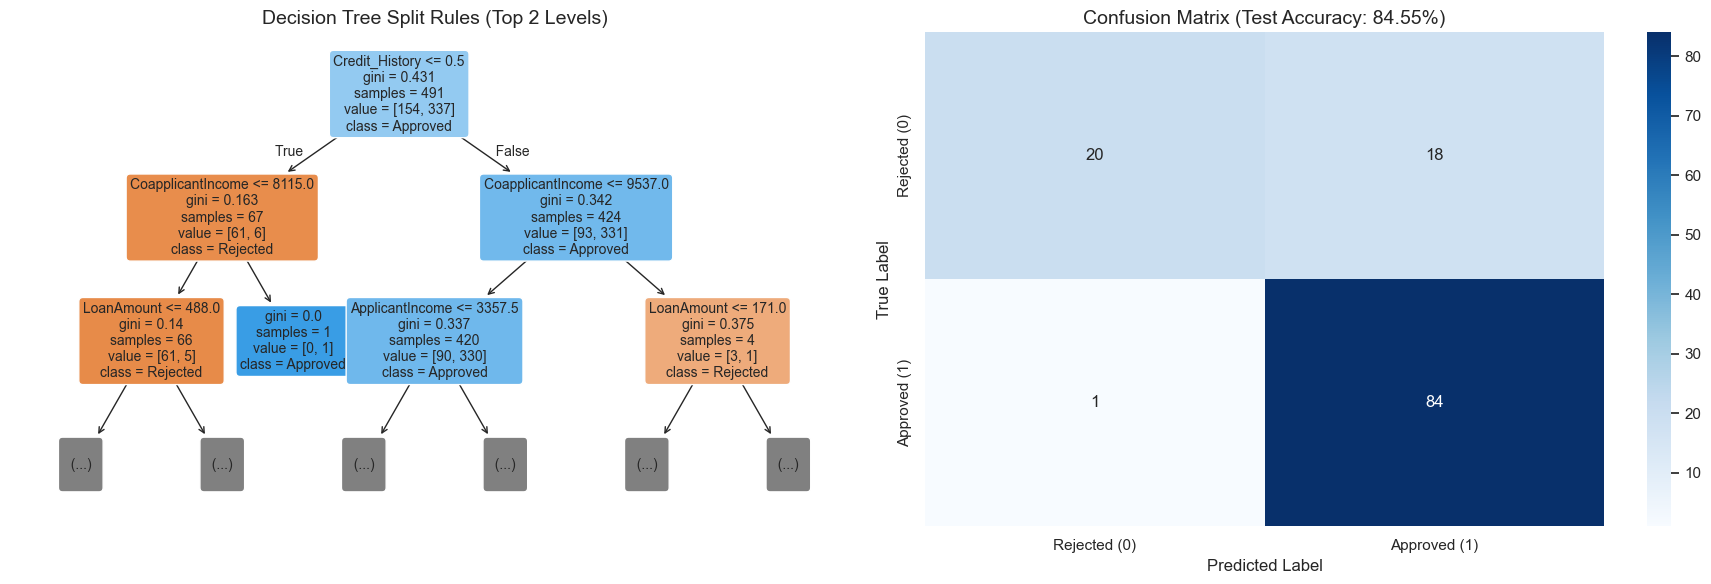

In [13]:
# Create a 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Visualizing the Decision Rules (Top 2 Levels)
plot_tree(
    dt_model,
    max_depth=2,
    feature_names=X_encoded.columns.tolist(),
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=axes[0]
)
axes[0].set_title("Decision Tree Split Rules (Top 2 Levels)", fontsize=14)

# 2. Confusion Matrix
y_pred = dt_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])
axes[1].set_title(f"Confusion Matrix (Test Accuracy: {test_acc*100:.2f}%)", fontsize=14)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

Here is a clear, paragraph-by-paragraph breakdown explaining both figures in detail.

---

### **Left Figure: Decision Tree Split Rules (Top 2 Levels)**

The decision tree visualization demonstrates how the trained model categorizes loan applicants based on specific feature thresholds:

* **Root Node (Level 0):** The primary decision driver is **`Credit_History`**. The root node evaluates whether an applicant's `Credit_History <= 0.5`. Out of all 491 training samples, 154 belong to class 0 (Rejected) and 337 belong to class 1 (Approved). Because `Credit_History` acts as a binary indicator ($0.0$ for poor credit, $1.0$ for good credit), applicants with no credit history (`<= 0.5`) take the **True** (left) branch, whereas applicants with good credit take the **False** (right) branch.


* **Left Branch (Poor Credit History):** For applicants routed left due to bad credit history, the model evaluates **`CoapplicantIncome <= 8115.0`** across 67 samples. For almost all of these applicants (61 out of 67), the loan status defaults to **Rejected** (orange nodes). However, if the coapplicant income exceeds 8115.0, the tree reaches a pure leaf node (`gini = 0.0`) approving the single applicant. For the remaining 66 applicants, the model further splits on **`LoanAmount <= 488.0`**.


* **Right Branch (Good Credit History):** For applicants routed right due to good credit history, the model evaluates **`CoapplicantIncome <= 9537.0`** across 424 samples. The vast majority (331 out of 424) are classified as **Approved** (blue nodes). If coapplicant income is below $9537, the model checks whether **`ApplicantIncome <= 3357.5`** to refine predictions for the 420 remaining applicants. If coapplicant income exceeds $9537, it evaluates whether **`LoanAmount <= 171.0`** across 4 samples.



---

### **Right Figure: Confusion Matrix (Test Accuracy: 84.55%)**

The confusion matrix presents the practical performance evaluation of the decision tree model on the 123 unseen test samples:

* **True Negatives (Top-Left, 20):** The model correctly predicted **Rejected** for 20 applicants who actually defaulted/got rejected.


* **False Positives (Top-Right, 18):** The model incorrectly predicted **Approved** for 18 applicants whose actual status was **Rejected**.


* **False Negatives (Bottom-Left, 1):** The model incorrectly predicted **Rejected** for only 1 applicant who was actually **Approved**.


* **True Positives (Bottom-Right, 84):** The model correctly predicted **Approved** for 84 applicants who were actually approved.



---

### **Overall Interpretation**

The total overall test accuracy reaches **84.55%** (calculated as $\frac{20 + 84}{123} = \frac{104}{123} \approx 84.55\%$). The model achieves an exceptionally high **Recall for Approved Loans** (84 out of 85 approved loans correctly detected, or ~98.8%), meaning it rarely denies creditworthy applicants. However, it is slightly more lenient on high-risk applicants, misclassifying 18 risky applicants as approved due to the heavy predictive weight placed on good credit history.

In [14]:
# Generate detailed metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])

print("--- DETAILED TEST SET METRICS ---")
print(f"Accuracy:  {test_acc * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%  (When model predicts Approved, it is right this often)")
print(f"Recall:    {recall * 100:.2f}%  (Model captures this percentage of all actual Approved loans)")
print(f"F1-Score:  {f1 * 100:.2f}%  (Harmonic mean balancing Precision and Recall)")
print(f"ROC-AUC:   {roc_auc:.4f}   (Model's overall class discrimination ability)")

print("\n--- FULL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

--- DETAILED TEST SET METRICS ---
Accuracy:  84.55%
Precision: 82.35%  (When model predicts Approved, it is right this often)
Recall:    98.82%  (Model captures this percentage of all actual Approved loans)
F1-Score:  89.84%  (Harmonic mean balancing Precision and Recall)
ROC-AUC:   0.7060   (Model's overall class discrimination ability)

--- FULL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Rejected (0)       0.95      0.53      0.68        38
Approved (1)       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



The evaluation metrics show that the model is exceptionally good at identifying creditworthy applicants—capturing 98.82% of all actual approved loans (Recall)—and maintains high precision when granting approvals, being correct 82.35% of the time. However, the breakdown reveals a clear class performance trade-off: while the model is conservative when rejecting applicants (95% precision for Class 0, meaning almost every rejection is justified), it only detects 53% of all actual defaults (Recall for Class 0), leading to 18 risky applicants being incorrectly approved. Overall, with an F1-score of 89.84% for approved loans and an ROC-AUC of 0.7060, the model functions as an effective, highly permissive loan approval filter that minimizes false rejections for good borrowers, though it could be tuned further to catch more potential default risks.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_900\1399187965.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance_filtered, palette='mako')


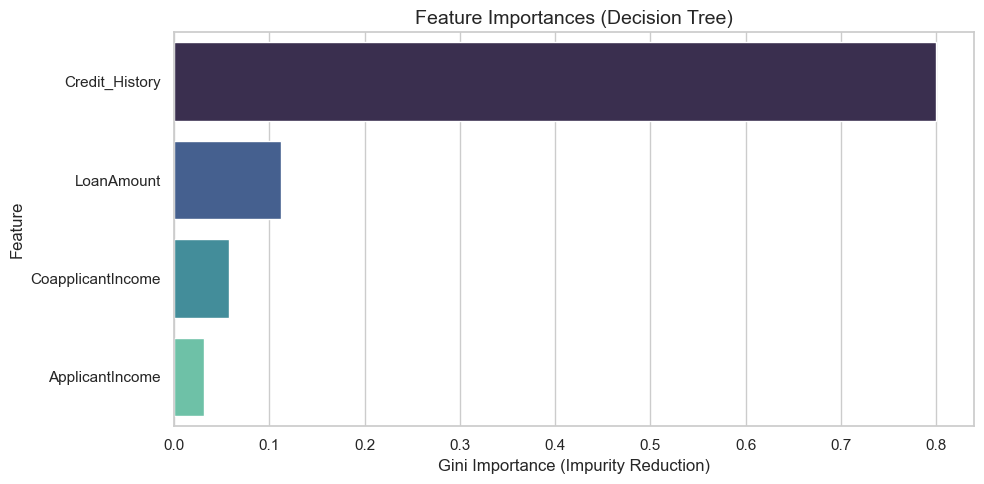

--- FEATURE IMPORTANCE SCORES ---


,Feature,Importance
0,Credit_History,0.799855
1,LoanAmount,0.111998
2,CoapplicantIncome,0.057269
3,ApplicantIncome,0.030878


In [15]:
# Extract feature importances from the trained model
importances = dt_model.feature_importances_
feature_names = X_encoded.columns

# Create a DataFrame sorted by importance score
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Filter out features with 0 importance for cleaner visualization
df_importance_filtered = df_importance[df_importance['Importance'] > 0]

# Plot top features
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance_filtered, palette='mako')
plt.title('Feature Importances (Decision Tree)', fontsize=14)
plt.xlabel('Gini Importance (Impurity Reduction)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Print exact importance values
print("--- FEATURE IMPORTANCE SCORES ---")
display(df_importance_filtered.reset_index(drop=True))

## Summary & Strategic Insights

### 1. Model Performance
- **Accuracy:** **84.55%** on unseen test data.
- **Approval Recall:** **98.82%**—the model successfully approves almost every qualified borrower.
- **Rejection Precision:** **95.00%**—when the model rejects an applicant, it is almost certainly a safe decision.

### 2. Primary Decision Drivers
1. **Credit History:** By far the single most influential variable in determining loan status.
2. **Coapplicant Income:** Functions as the secondary safeguard for applicants with poor credit or borderline application profiles.
3. **Loan Amount & Applicant Income:** Acts as fine-tuning thresholds for final risk adjustment.

### 3. Business Recommendations
- **Automated Approvals:** High-credit applicants with standard coapplicant incomes can be fast-tracked for automated instant approval.
- **Manual Review Flag:** Because the model misclassifies ~47% of actual defaults as approvals (low rejection recall), applicants with weak credit or high requested loan amounts should be routed to human underwriters for manual review rather than relying on automated approval alone.

In [17]:
import joblib

# 1. Save the trained Decision Tree model
joblib.dump(dt_model, 'loan_decision_tree_model.joblib')

# 2. Save the list of encoded feature names (ensures matching input structure later)
joblib.dump(X_encoded.columns.tolist(), 'model_features.joblib')

print("Model and feature names saved successfully!")
print("Saved files:")
print("  - loan_decision_tree_model.joblib")
print("  - model_features.joblib")

Model and feature names saved successfully!
Saved files:
  - loan_decision_tree_model.joblib
  - model_features.joblib


In [18]:
import pandas as pd
import joblib

def predict_loan_status(applicant_data):
    """
    Takes a dictionary of raw applicant data, formats it to match model features,
    and returns loan approval prediction and probability.
    """
    # 1. Load saved model and expected feature names
    model = joblib.load('loan_decision_tree_model.joblib')
    expected_features = joblib.load('model_features.joblib')
    
    # 2. Convert input dict to DataFrame
    df_input = pd.DataFrame([applicant_data])
    
    # 3. Apply One-Hot Encoding
    df_encoded = pd.get_dummies(df_input)
    
    # 4. Reindex to align with training features (fill missing columns with 0/False)
    df_encoded = df_encoded.reindex(columns=expected_features, fill_value=0)
    
    # 5. Make prediction
    prediction = model.predict(df_encoded)[0]
    probability = model.predict_proba(df_encoded)[0][1]
    
    # 6. Format Result
    status = "APPROVED" if prediction == 1 else "REJECTED"
    
    print("\n--- LOAN APPLICATION RESULT ---")
    print(f"Decision:             {status}")
    print(f"Approval Probability: {probability * 100:.1f}%")
    
    if prediction == 1:
        print("Reasoning: Meets financial thresholds and positive credit history criteria.")
    else:
        print("Reasoning: Flagged due to credit history risk or debt-to-income ratio.")

    return prediction, probability

In [19]:
# Sample Applicant 1: Strong Profile (Good Credit, Solid Income)
applicant_1 = {
    'ApplicantIncome': 6000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1.0,  # 1.0 = Good Credit History
    'Gender': 'Male',
    'Married': 'Yes',
    'Dependents': '1',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'Property_Area': 'Semiurban'
}

# Sample Applicant 2: High Risk Profile (Bad Credit History)
applicant_2 = {
    'ApplicantIncome': 2500,
    'CoapplicantIncome': 0,
    'LoanAmount': 200,
    'Loan_Amount_Term': 360,
    'Credit_History': 0.0,  # 0.0 = Poor Credit History
    'Gender': 'Male',
    'Married': 'No',
    'Dependents': '0',
    'Education': 'Not Graduate',
    'Self_Employed': 'No',
    'Property_Area': 'Urban'
}

print("=== APPLICANT 1 TEST ===")
predict_loan_status(applicant_1)

print("\n=== APPLICANT 2 TEST ===")
predict_loan_status(applicant_2)

=== APPLICANT 1 TEST ===

--- LOAN APPLICATION RESULT ---
Decision:             APPROVED
Approval Probability: 76.6%
Reasoning: Meets financial thresholds and positive credit history criteria.

=== APPLICANT 2 TEST ===

--- LOAN APPLICATION RESULT ---
Decision:             REJECTED
Approval Probability: 16.7%
Reasoning: Flagged due to credit history risk or debt-to-income ratio.


(np.int64(0), np.float64(0.16666666666666666))

In [20]:
from sklearn.tree import export_text

# 1. Print the human-readable text rules of the trained tree
print("=== DECISION TREE RULE STRUCTURE (Top Levels) ===")
tree_rules = export_text(
    dt_model,
    feature_names=X_encoded.columns.tolist(),
    max_depth=3
)
print(tree_rules)

# 2. Function to trace decision path for any applicant
def trace_applicant_path(applicant_dict):
    df_input = pd.DataFrame([applicant_dict])
    df_encoded = pd.get_dummies(df_input).reindex(columns=X_encoded.columns, fill_value=0)
    
    # Extract decision path node indices
    node_indicator = dt_model.decision_path(df_encoded)
    leaf_id = dt_model.apply(df_encoded)[0]
    node_index = node_indicator.indices
    
    feature_names = X_encoded.columns.tolist()
    
    print(f"\n--- DECISION PATH TRACE FOR APPLICANT ---")
    for node_id in node_index:
        if leaf_id == node_id:
            print(f"-> Node {node_id}: LEAF NODE REACHED")
            break
            
        feature_idx = dt_model.tree_.feature[node_id]
        threshold = dt_model.tree_.threshold[node_id]
        feature_name = feature_names[feature_idx]
        value = df_encoded.iloc[0, feature_idx]
        
        if value <= threshold:
            comparison = "<="
            direction = "True (Left)"
        else:
            comparison = ">"
            direction = "False (Right)"
            
        print(f"-> Node {node_id}: Split on [{feature_name}]")
        print(f"   Value: {value} {comparison} Threshold: {threshold:.2f} ==> Go {direction}")

# Trace Applicant 1 (Good Credit)
print("\n" + "="*50)
print("TRACING APPLICANT 1 (Good Credit History)")
trace_applicant_path(applicant_1)

# Trace Applicant 2 (Poor Credit)
print("\n" + "="*50)
print("TRACING APPLICANT 2 (Poor Credit History)")
trace_applicant_path(applicant_2)

=== DECISION TREE RULE STRUCTURE (Top Levels) ===
|--- Credit_History <= 0.50
|   |--- CoapplicantIncome <= 8115.00
|   |   |--- LoanAmount <= 488.00
|   |   |   |--- LoanAmount <= 156.00
|   |   |   |   |--- class: 0
|   |   |   |--- LoanAmount >  156.00
|   |   |   |   |--- class: 0
|   |   |--- LoanAmount >  488.00
|   |   |   |--- class: 1
|   |--- CoapplicantIncome >  8115.00
|   |   |--- class: 1
|--- Credit_History >  0.50
|   |--- CoapplicantIncome <= 9537.00
|   |   |--- ApplicantIncome <= 3357.50
|   |   |   |--- LoanAmount <= 76.50
|   |   |   |   |--- class: 1
|   |   |   |--- LoanAmount >  76.50
|   |   |   |   |--- class: 1
|   |   |--- ApplicantIncome >  3357.50
|   |   |   |--- LoanAmount <= 95.50
|   |   |   |   |--- class: 1
|   |   |   |--- LoanAmount >  95.50
|   |   |   |   |--- class: 1
|   |--- CoapplicantIncome >  9537.00
|   |   |--- LoanAmount <= 171.00
|   |   |   |--- class: 1
|   |   |--- LoanAmount >  171.00
|   |   |   |--- class: 0


TRACING APPLICANT 1 

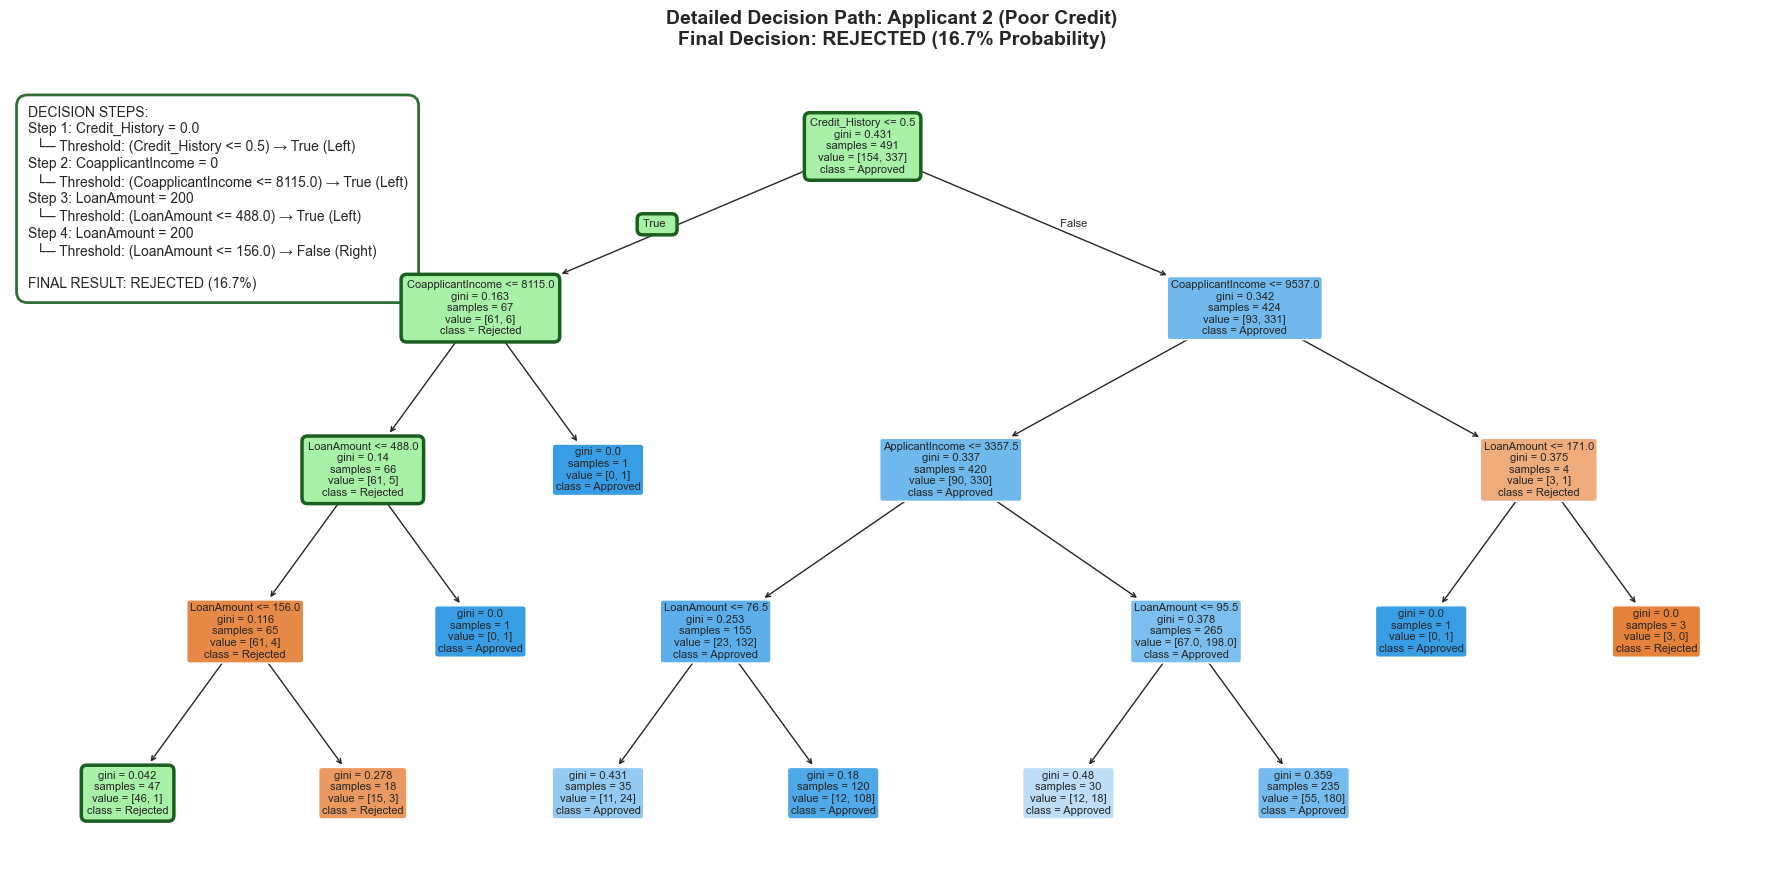

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

def visualize_applicant_path_detailed(applicant_dict, title="Applicant Decision Path"):
    """
    Plots the Decision Tree up to depth 4, highlights active green nodes,
    and displays an explicit step-by-step decision box on the plot.
    """
    # 1. Format input data
    df_input = pd.DataFrame([applicant_dict])
    df_encoded = pd.get_dummies(df_input).reindex(columns=X_encoded.columns, fill_value=0)
    
    # 2. Extract decision path nodes and steps
    node_indicator = dt_model.decision_path(df_encoded)
    active_node_ids = set(node_indicator.indices)
    leaf_id = dt_model.apply(df_encoded)[0]
    
    feature_names = X_encoded.columns.tolist()
    step_descriptions = []
    
    for step_num, node_id in enumerate(node_indicator.indices):
        if node_id == leaf_id:
            break
        feature_idx = dt_model.tree_.feature[node_id]
        threshold = dt_model.tree_.threshold[node_id]
        feat_name = feature_names[feature_idx]
        val = df_encoded.iloc[0, feature_idx]
        
        is_true = val <= threshold
        direction = "True (Left)" if is_true else "False (Right)"
        symbol = "<=" if is_true else ">"
        
        step_text = f"Step {step_num+1}: {feat_name} = {val}\n  └─ Threshold: ({feat_name} <= {threshold:.1f}) → {direction}"
        step_descriptions.append(step_text)
    
    # 3. Create plot figure
    fig, ax = plt.subplots(figsize=(18, 9))
    
    # Render tree with max_depth=4 so the final leaf is fully visible
    annotations = plot_tree(
        dt_model,
        max_depth=4,
        feature_names=feature_names,
        class_names=['Rejected', 'Approved'],
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax
    )
    
    # 4. Highlight active nodes in green
    for node_id, annotation in enumerate(annotations):
        if node_id in active_node_ids:
            annotation.set_bbox(dict(
                boxstyle='round,pad=0.5',
                facecolor='#a8f0a5',
                edgecolor='#1b5e20',
                linewidth=2.5
            ))
            
    # 5. Add step-by-step decision log overlay box on the chart
    pred = dt_model.predict(df_encoded)[0]
    prob = dt_model.predict_proba(df_encoded)[0][1]
    status = "APPROVED" if pred == 1 else "REJECTED"
    
    path_summary_text = f"DECISION STEPS:\n" + "\n".join(step_descriptions) + f"\n\nFINAL RESULT: {status} ({prob*100:.1f}%)"
    
    plt.text(
        0.01, 0.95, path_summary_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.9, edgecolor='#1b5e20', linewidth=2)
    )
    
    plt.title(f"{title}\nFinal Decision: {status} ({prob*100:.1f}% Probability)", fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# Run the detailed visualization for Applicant 2
visualize_applicant_path_detailed(applicant_2, title="Detailed Decision Path: Applicant 2 (Poor Credit)")